In [22]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
# Step 2: Load dataset using read_csv()

df = pd.read_csv("HousingData.csv")

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [24]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [25]:
df = df.dropna()

In [26]:
# Step 3: Separate input and output

X = df.drop("MEDV", axis=1)   # Input features
y = df["MEDV"]                # Target column


In [27]:
# Step 4: Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
# Step 5: Normalize the data

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# Step 6: Create Deep Neural Network model

model = Sequential()

# First Hidden Layer
model.add(Dense(64, activation='relu', input_dim=13))

# Second Hidden Layer
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1))

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# Step 7: Compile the model

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [31]:
# Step 8: Train the model

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 556.1106 - mae: 21.7047 - val_loss: 489.8176 - val_mae: 20.7564
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 505.2210 - mae: 20.5100 - val_loss: 441.3561 - val_mae: 19.5766
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 352ms/step - loss: 441.7767 - mae: 18.9991 - val_loss: 378.2667 - val_mae: 17.9126
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 361.2608 - mae: 16.8606 - val_loss: 293.4203 - val_mae: 15.4326
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 261.7104 - mae: 14.0263 - val_loss: 199.8103 - val_mae: 12.1910
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 165.6312 - mae: 10.7615 - val_loss: 123.3743 - val_mae: 8.9281
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 93.6013 - mae: 7.8927 - val_loss: 83.4888 - val_mae: 6.7227
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 62.0847 - mae: 6.2897 - val_loss: 65.3002 - val_mae: 5.6929
Epoch 9/100
16/1

In [32]:
loss,mae=model.evaluate(X_test,y_test)
print(f"Mean Squared Error",loss)
print(f"Mean Absolute Error", mae)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 23.2933 - mae: 2.6122
Mean Squared Error 23.293336868286133
Mean Absolute Error 2.6121792793273926


In [33]:
predictions = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE: ",rmse)
# Compute R² Score
r2 = r2_score(y_test, predictions)
print(f"R2 Score : ",r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step 
RMSE:  4.826317089011142
R2 Score :  0.7238372986882653


In [36]:
for i in range(10):
    print("Actual Values:", y_test.iloc[i])
    print("Predicted Price:", predictions[i])
    print("---------------------------")

Actual Values: 25.0
Predicted Price: [24.76507]
---------------------------
Actual Values: 18.6
Predicted Price: [18.160442]
---------------------------
Actual Values: 21.0
Predicted Price: [18.50227]
---------------------------
Actual Values: 23.5
Predicted Price: [26.999454]
---------------------------
Actual Values: 17.5
Predicted Price: [18.22949]
---------------------------
Actual Values: 33.8
Predicted Price: [35.1982]
---------------------------
Actual Values: 19.7
Predicted Price: [18.766144]
---------------------------
Actual Values: 24.8
Predicted Price: [28.8997]
---------------------------
Actual Values: 32.0
Predicted Price: [31.275251]
---------------------------
Actual Values: 14.0
Predicted Price: [13.799992]
---------------------------


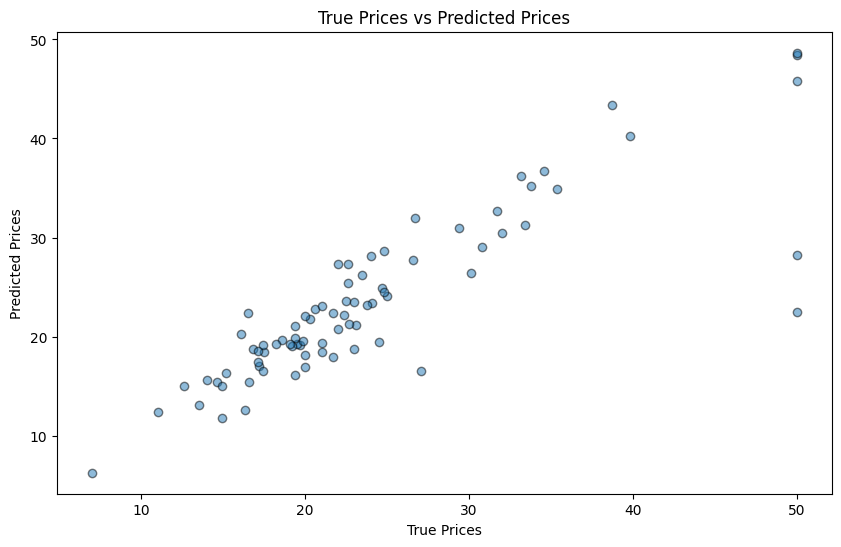

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions,alpha=0.5, edgecolors='k') 
plt.xlabel("True Prices")
plt.ylabel("Predicted Prices")
plt.title("True Prices vs Predicted Prices")
plt.show()